In [1]:
import yfinance as yf; 
import numpy as np; 
import pandas as pd; 


tickers = [
    'AAPL', 'MSFT', 'NVDA', 'AMZN', 'JPM', 'BAC', 'PYPL', 'MSTR',
    'VOO', 'QQQ', 'VXUS', 'VWO',
    'BND', 'GLD', 'VNQ'
]; 

prices = yf.download(
    tickers=tickers,
    start='2020-07-01',
    end='2025-06-30',
    auto_adjust=True
)['Close']; 

prices = prices.sort_index().dropna(); 
returns = prices.pct_change(); 
returns = returns.replace([-np.inf, np.inf], np.nan).dropna(); 

trading_days = 252; 

mu_daily = returns.mean(); 
cov_daily = returns.cov(); 
mu_annual = mu_daily * trading_days; 
cov_annual = cov_daily * trading_days; 

[*********************100%***********************]  15 of 15 completed


In [2]:
from lagrangian_solver import lg_solve; 
from qp_solver import qp_solve; 

for r in [0.1, 0.2, 0.3, 0.4, 0.5]:
    weights_lg = lg_solve(mu_annual, cov_annual, r); 
    returns_lg = weights_lg.T @ mu_annual; 
    variance_lg = weights_lg.T @ cov_annual @ weights_lg; 

    weights_qp = qp_solve(mu_annual, cov_annual, r); 
    returns_qp = weights_qp.T @ mu_annual; 
    variance_qp = weights_qp.T @ cov_annual @ weights_qp; 

    print(r, end=" ")
    print(np.max(np.abs(weights_lg - weights_qp)), end=" "); 
    print(np.abs(returns_lg - returns_qp), end=" "); 
    print(np.abs(variance_lg - variance_qp)); 

target_returns = np.linspace(mu_annual.min(), mu_annual.max(), 50); 

max_weight_error = 0; 
max_return_error = 0; 
max_variance_error = 0; 
weight_error = []; 
for r in target_returns:
    weights_lg = lg_solve(mu_annual, cov_annual, r); 
    returns_lg = weights_lg.T @ mu_annual; 
    variance_lg = weights_lg.T @ cov_annual @ weights_lg; 

    weights_qp = qp_solve(mu_annual, cov_annual, r); 
    returns_qp = weights_qp.T @ mu_annual; 
    variance_qp = weights_qp.T @ cov_annual @ weights_qp; 

    max_weight_error = max(max_weight_error, np.max(np.abs(weights_lg - weights_qp))); 
    weight_error.append(np.sum(np.abs(weights_lg - weights_qp))); 
    max_return_error = max(max_return_error, np.abs(returns_lg - returns_qp)); 
    max_variance_error = max(max_variance_error, np.abs(variance_lg - variance_qp)); 

print(max_weight_error); 
print(np.asarray(weight_error).mean()); 
print(max_return_error); 
print(max_variance_error); 

0.1 1.0380585280245214e-13 1.249000902703301e-16 4.336808689942018e-18
0.2 1.4876988529977098e-13 1.6653345369377348e-16 1.5612511283791264e-17
0.3 1.8984813721090177e-13 5.551115123125783e-17 6.938893903907228e-18
0.4 2.389199948993337e-13 1.1102230246251565e-16 1.734723475976807e-17
0.5 2.653433028854124e-13 1.1102230246251565e-16 1.3877787807814457e-17
5.382361223382759e-13
7.297531654480716e-13
6.661338147750939e-16
1.6653345369377348e-16


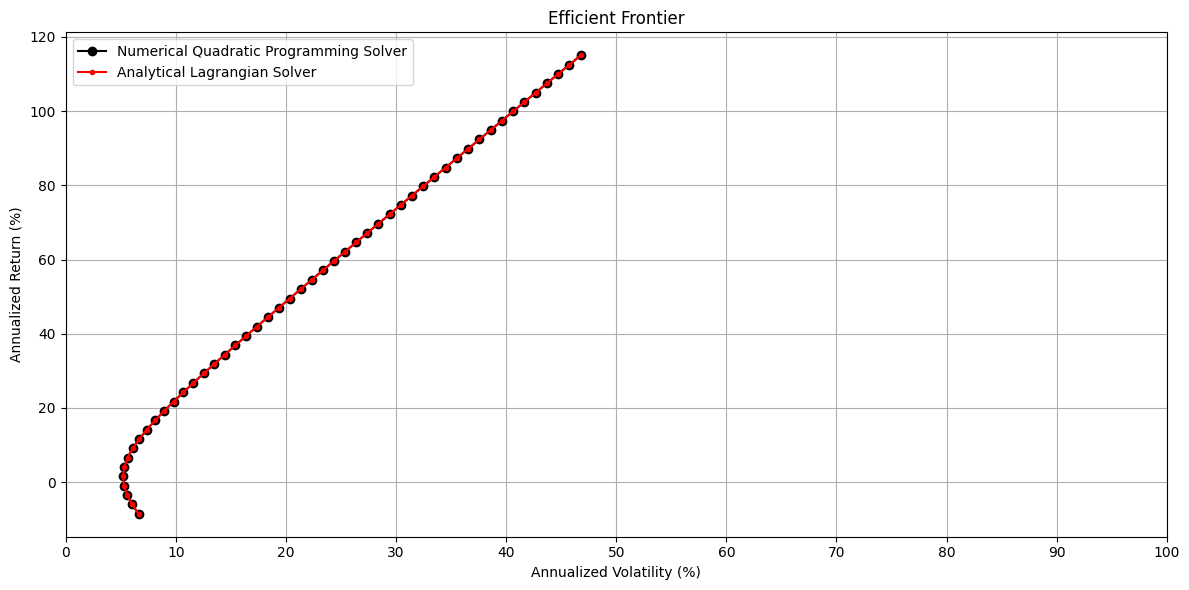

In [3]:
import matplotlib.pyplot as plt; 

frontier_returns = []; 
frontier_volatilities = []; 
frontier_weights = []; 

frontier_returns2 = []; 
frontier_volatilities2 = []; 
frontier_weights2 = []; 

for r in target_returns:
    w = qp_solve(mu_annual, cov_annual, r); 
    if w is not None:
        portf_return = mu_annual @ w; 
        portf_variance = w.T @ cov_annual @ w; 
        portf_volatility = np.sqrt(portf_variance); 

        frontier_returns.append(portf_return); 
        frontier_volatilities.append(portf_volatility); 
        frontier_weights.append(w); 

    w2 = lg_solve(mu_annual, cov_annual, r); 
    if w2 is not None:
        portf_return = mu_annual @ w2; 
        portf_variance = w2.T @ cov_annual @ w2; 
        portf_volatility = np.sqrt(portf_variance); 

        frontier_returns2.append(portf_return); 
        frontier_volatilities2.append(portf_volatility); 
        frontier_weights2.append(w2); 


frontier = pd.DataFrame({
    "Return": frontier_returns,
    "Volatility": frontier_volatilities
}); 

frontier2 = pd.DataFrame({
    "Return": frontier_returns2,
    "Volatility": frontier_volatilities2
}); 

asset_returns = mu_annual; 
asset_volatilities = pd.Series(np.sqrt(np.diag(cov_annual)), index=returns.columns); 

plt.figure(figsize=(12,6)); 
plt.plot(frontier["Volatility"] * 100, frontier["Return"] * 100, marker="o", color="black", label="Numerical Quadratic Programming Solver"); 
plt.plot(frontier2["Volatility"] * 100, frontier2["Return"] * 100, marker=".", color="red", label="Analytical Lagrangian Solver"); 

plt.legend(loc="upper left", bbox_to_anchor=(0, 1))

plt.xlabel("Annualized Volatility (%)"); 
plt.xticks(np.arange(0, 101, 10)) 
plt.ylabel("Annualized Return (%)"); 
plt.title("Efficient Frontier"); 
plt.grid(True); 
plt.tight_layout(); 
plt.show(); 

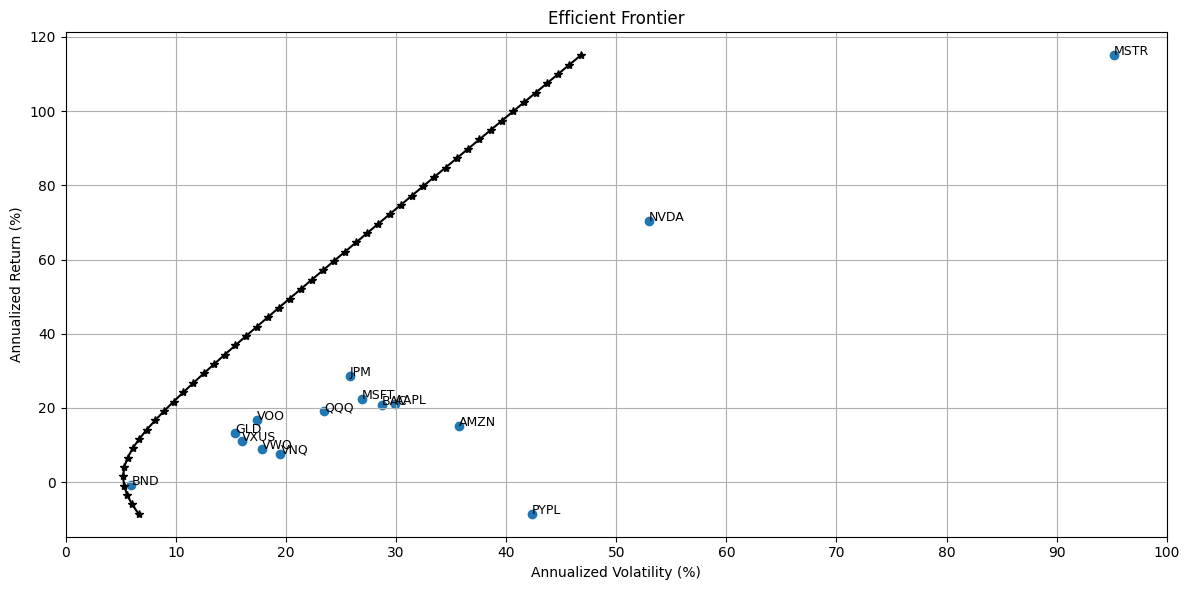

In [4]:
import matplotlib.pyplot as plt; 

frontier_returns = []; 
frontier_volatilities = []; 
frontier_weights = []; 

for r in target_returns:
    w = qp_solve(mu_annual, cov_annual, r); 
    if w is not None:
        w = pd.Series(w, index=returns.columns); 
        portf_return = mu_annual @ w; 
        portf_variance = w.T @ cov_annual @ w; 
        portf_volatility = np.sqrt(portf_variance); 

        frontier_returns.append(portf_return); 
        frontier_volatilities.append(portf_volatility); 
        frontier_weights.append(w); 


frontier = pd.DataFrame({
    "Return": frontier_returns,
    "Volatility": frontier_volatilities
}); 

asset_returns = mu_annual; 
asset_volatilities = pd.Series(np.sqrt(np.diag(cov_annual)), index=returns.columns); 

plt.figure(figsize=(12,6)); 
plt.plot(frontier["Volatility"] * 100, frontier["Return"] * 100, marker="*", color="black"); 
plt.scatter(asset_volatilities * 100, asset_returns * 100); 

for ticker in returns.columns:
    plt.annotate(
        ticker,
        (asset_volatilities[ticker] * 100, asset_returns[ticker] * 100),
        fontsize=9
    ); 

plt.xlabel("Annualized Volatility (%)"); 
plt.xticks(np.arange(0, 101, 10)) 
plt.ylabel("Annualized Return (%)"); 
plt.title("Efficient Frontier"); 
plt.grid(True); 
plt.tight_layout(); 
plt.show(); 

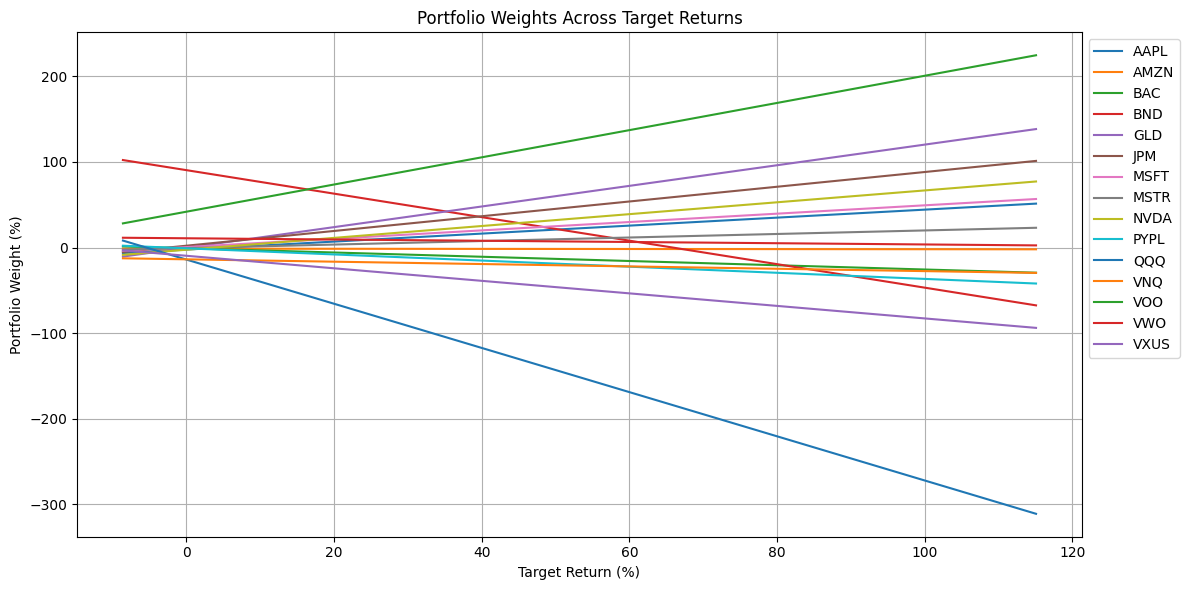

In [5]:
weights_df = pd.DataFrame(frontier_weights)
weights_df["Target Return"] = target_returns

plt.figure(figsize=(12, 6))

for ticker in returns.columns:
    plt.plot(
        weights_df["Target Return"] * 100,
        weights_df[ticker] * 100,
        label=ticker
    )

plt.xlabel("Target Return (%)")
plt.ylabel("Portfolio Weight (%)")
plt.title("Portfolio Weights Across Target Returns")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
test_prices = yf.download(
    tickers=tickers,
    start='2025-07-01',
    end='2026-06-30',
    auto_adjust=True
)['Close']
test_prices.dropna()

def simulate(weights):
    initial_capital = 100_000
    initial_prices = test_prices.iloc[0]

    shares = (weights * initial_capital) / initial_prices

    portfolio_value = test_prices.mul(shares, axis=1).sum(axis=1)

    daily_returns = portfolio_value.pct_change().dropna()
    annual_return = (portfolio_value.iloc[-1] - portfolio_value.iloc[0]) / portfolio_value.iloc[0] 
    annual_volatility = daily_returns.std() * np.sqrt(252)

    sharpe_ratio = annual_return / annual_volatility   # assuming risk-free = 0

    running_max = portfolio_value.cummax()
    drawdown = (portfolio_value - running_max) / running_max
    max_drawdown = drawdown.min()

    return {
        "Portfolio value": portfolio_value,
        "Annual return": annual_return,
        "Annual volatility": annual_volatility,
        "Sharpe ratio": sharpe_ratio,
        "Max drawdown": max_drawdown
    }

[*********************100%***********************]  15 of 15 completed


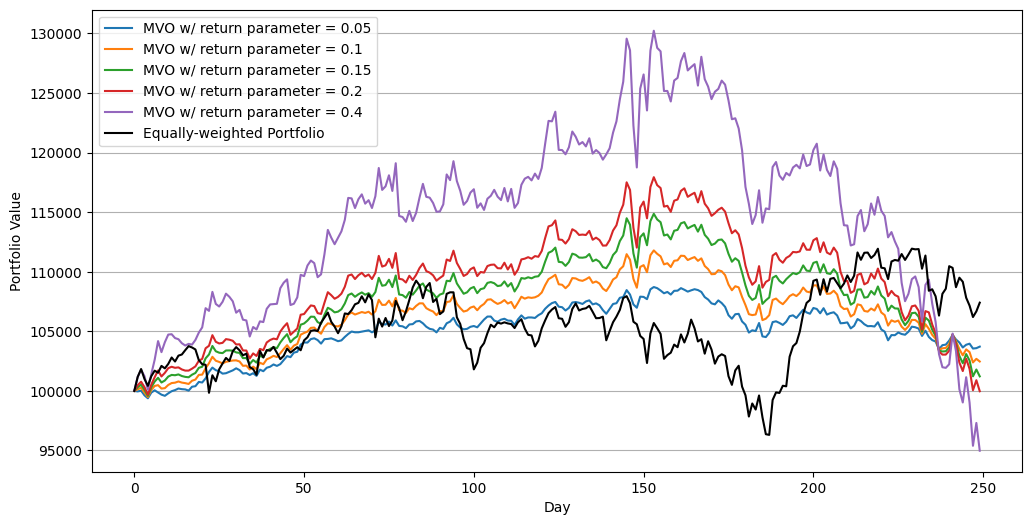

In [36]:
range_x = [i for i in range(250)]

eq_weights = pd.array([1/len(tickers)] * len(tickers))

plt.figure(figsize=(12,6))

sim = simulate(eq_weights)
plt.plot(range_x, sim["Portfolio value"], color="black", label="Equally-weighted Portfolio")
# print(sim["Annual return"], sim["Annual volatility"], sim["Sharpe ratio"], sim["Max drawdown"])

for r in [0.05, 0.1, 0.15, 0.2, 0.4]:
    mvo_weights = lg_solve(mu_annual, cov_annual, r)
    sim = simulate(mvo_weights)
    # print(sim["Annual return"], sim["Annual volatility"], sim["Sharpe ratio"], sim["Max drawdown"])
    plt.plot(range_x, sim["Portfolio value"], label=f"MVO w/ return parameter = {r}")
    

plt.xlabel("Day")
plt.ylabel("Portfolio Value")
plt.legend(loc="upper left", bbox_to_anchor=(0, 1))
plt.grid(True, axis='y')
plt.show()